In [16]:
import os
import sys
import numpy as np
import dask.dataframe as dd
from sklearn import preprocessing
from sklearn.cluster import KMeans
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src import calc

In [17]:
solar_data = dd.read_parquet('~/Projects/ephin-predict/datasets/ephin_1995_1996/*')
# total_rows = solar_data.shape[0].compute()
total_rows = 6832023
# print(f'{total_rows} in 1995-1996') # print and save for next time

In [18]:
# let's use a small random sample and see if clusters appear
sample_data = solar_data.sample(frac=0.01)
sample_data = sample_data.dropna(how='any')

In [19]:
# first let's calculate our energies up to C
sample_data['de/dx'] = sample_data.apply(calc.calc_de_dx, axis=1)
sample_data['ABC'] = sample_data.apply(calc.calc_total_energy, axis=1, to_d=False, to_e=False)

In [20]:

# for now, let's assume 4 categories: electrons, protons, helium nuclei, and noisy somethings
kmeans = KMeans(4)
labels = dd.from_array(kmeans.fit_predict(sample_data))
labels.name = 'group'

sample_data = sample_data.merge(labels.to_frame())

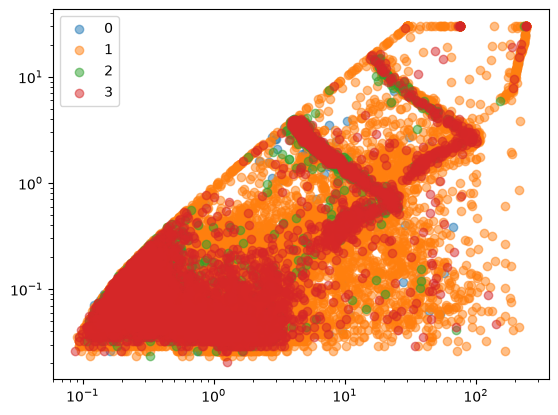

In [21]:
# Let's take a quick look at clusters using the de/dx vs ABC scatter
import matplotlib.pyplot as plt
import pandas as pd

fig, ax = plt.subplots(1,)
ax.set_xscale("log")
ax.set_yscale("log")

for group in np.unique(labels):
    grouped_data = sample_data.query(f'group == {group}').compute()
    ax.scatter(grouped_data['ABC'], grouped_data['de/dx'], label=group, alpha=0.5)
ax.legend()

plt.show()

In [22]:
'''
Not great - looks like the groups are actually clustering to something else besides the particle type
Maybe it's some operating state

Orange - all noise
Red - looks like a very de-noise graph
Green - mostly overwritten by red - nnneeds more investigation
blue - obliterated by orange - 

'''
corr = sample_data.corr().compute()
best = corr['group'].nlargest(10)
print(best)

group        1.000000
ms_of_day    0.184761
e300         0.089922
e150         0.080636
b00          0.073268
b04          0.072696
b03          0.071255
b01          0.070655
e1300        0.070395
b02          0.070313
Name: group, dtype: float64


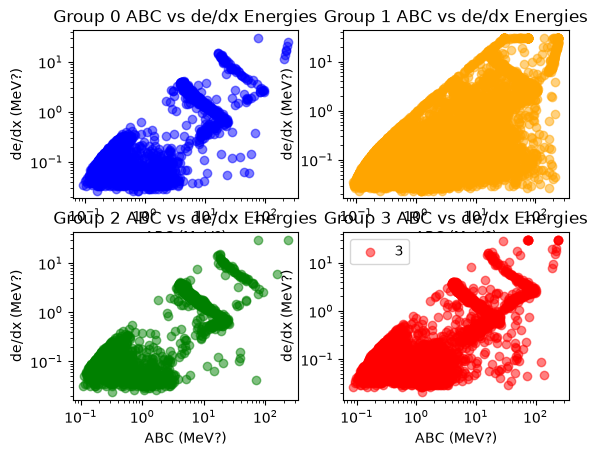

In [24]:
'''
obviously there's going to be perfect correlation the group label itself, but let's look at the others
okay thats insane - ms of day?????
let's plot each group indvidiually
'''

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2)
graphs = [ax1, ax2, ax3, ax4]
colors = ['blue', 'orange', 'green', 'red']

for group in np.unique(labels):
    ax = graphs[group]
    color = colors[group]
    grouped_data = sample_data.query(f'group == {group}').compute()
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(f'Group {group} ABC vs de/dx Energies')
    
    ax.set_xlabel('ABC (MeV?)')
    ax.set_ylabel('de/dx (MeV?)')
    ax.scatter(grouped_data['ABC'], grouped_data['de/dx'], c=color, label=group, alpha=0.5)
    
ax.legend()


Conclusion thus far: the current data as-is is actually not very predictive/distinct
We probably need to produce much stronger meta parameters
More notes - given shape of data, standard anisotropy might be bad, there's no circles nor ellipses

energy loss in A to ABC is a function ish, but not vice versa (2 diff A measures can give same ABC result)
^ so should produce 2 very different D + E measurements (we expect a linearish relationship for total energy loss, so the D + E must be diff

Moreover, I would assume a similar shape with A vs ABCD, with the "point" shifted further downwards towards as A gets lower
So let's maybe design new parameters


# New hyper parameters spitballing
I'm concerned about using A, B, and C, as they are all correlated. Maybe I should use PCA?
## Angle of incidence between A and B
The "error" of our prediction increases as the angle of the particle relative to the sensor increases. This is categorical, but we can encode it via integer?
### Super tight (0)
seg a == seg b and seg a == 0
### pretty straight(1)
seg a == seg b and seg a != 0
### angled (2)
seg a != seg b and (seg a == 0 or seg b == 0 or seg a - seg b == 1 mod 5 seg a - seg b == 4 mod 5
### very angled (3)
fallback
## loss in A
approx -de/dx, which is inversely proportional to total energy measured across ABCDE
## Predictions for energy spitballing
$$
\begin{align}
-\frac{dE}{dx} &\propto \frac{1}{E}\log \left(kE\right)\\
-\frac{dE}{dx} &\approx \Delta_{A}\\
\Delta_{A} &\propto \frac{1}{E}\log \left(kE\right)\\
E \left( \Delta_{A}\right) &\propto \log k + \log E\\
\log E &\approx 0\\
E \left( \Delta_{A}\right) &\propto \log k\\
\log \left( E \left( \Delta_{A}\right) \right) &\propto \log \left( \log k\right) \\
\log \left( E \right) + \log \left( \Delta_{A}\right) &\propto \log \left( \log k \right) \\
\log \left( E \right) &\propto \log \left( \log k \right) - \log \left( \Delta_{A}\right) \\
\log \left( E \right) &\propto \log \left( \frac{\log k}{\Delta_{A}}\right)\\
E &\propto \frac{\log k}{\Delta_{A}}\\
\end{align}
$$
Then, $\log k$ is a constant that can be calculated per species. (probably need to get some numbers - check diagram from slides?)
Is this guesstimate for E better than just using the sum of readings from ABC?

Or - for identification, we generate a prediction assuming its a proton or helium-4, and take the difference of that prediction vs ABC, and we have a form of clustering because the numbers for a mismatch will be much larger in magnitude?
## status flags
Did not see anything thus far that indicates a strong cluster. Maybe only shows up with other years in play (1995-1996 is anomalous in that all 5 sensors look okay)
## time of day
Is there a daily cycle?? it was a relatively weak correlation

### whoopsies
# clustering is a form of unsupervised learning itself - classifying first and then predicting based off of cluster is effectively the same as just predicting based on inputs
# need to group correlated data to prevent over/under rep
# counts maybe not helpful?
# normal PCA just blows up my cmputer
# need to some kind of incremental or dimensionality reduction as we go?
# NANs in data what do - assume 0 or remove